# QDA
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score

-----------------------


## Helpfull code

---------------------------

## Load Data

In [2]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [3]:
y = spaceship_data["Transported"].astype(int)
X = spaceship_data.drop(columns=["Transported", "GroupId"])

-----------------------

## Train-Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

-------------------------

## QDA Model

In [6]:
qda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("qda", QDA())
])

param_grid = {
    "qda__reg_param": np.linspace(0.0, 0.2, 20)
}

qda_grid = GridSearchCV(
    qda_pipe,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

qda_grid.fit(x_train, y_train)

print("Best QDA params:", qda_grid.best_params_)
print(f"Best CV accuracy: {100 * qda_grid.best_score_:.2f}%")

best_model = qda_grid.best_estimator_

Best QDA params: {'qda__reg_param': np.float64(0.0)}
Best CV accuracy: 75.80%


c:\Users\Liad M\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\Liad M\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [7]:
results_df = pd.DataFrame(qda_grid.cv_results_)

# עמודות חשובות בלבד
cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_qda__reg_param"
]

top5 = (
    results_df[cols]
    .sort_values(by="mean_test_score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

# באחוזים נוחים לקריאה
top5["mean_test_score"] = top5["mean_test_score"] * 100
top5["std_test_score"]  = top5["std_test_score"] * 100

top5

,rank_test_score,mean_test_score,std_test_score,param_qda__reg_param
0,1,75.799715,1.613228,0.000000
1,2,73.448273,1.640098,0.200000
2,3,73.243787,1.603521,0.189474
3,4,73.024692,1.673571,0.178947
4,5,72.966276,1.674649,0.168421


## Results

In [8]:
best_model = qda_grid.best_estimator_

In [9]:
y_pred_qda_train  = best_model.predict(x_train)
y_score_qda_train = best_model.predict_proba(x_train)[:, 1]

In [10]:
train_acc_qda = accuracy_score(y_train, y_pred_qda_train)

In [11]:
print("="*40)
print("BEST QDA — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_qda*100:.2f}%")
print("="*40)

BEST QDA — TRAIN SET PERFORMANCE
Accuracy : 74.24%


מטריצת ערבול למודל המוצלח ביותר TRAIN

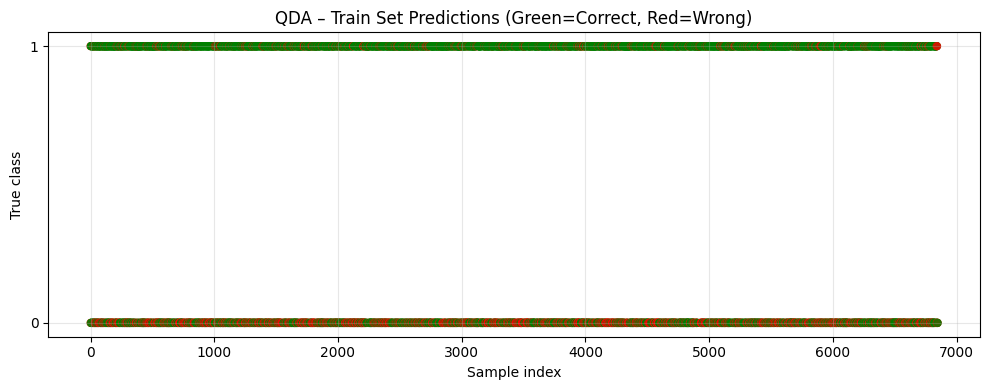

Errors: 1764 / 6847


In [12]:
correct = (y_pred_qda_train == y_train)

colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_train)), y_train, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")  
plt.ylabel("True class")
plt.title("QDA – Train Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

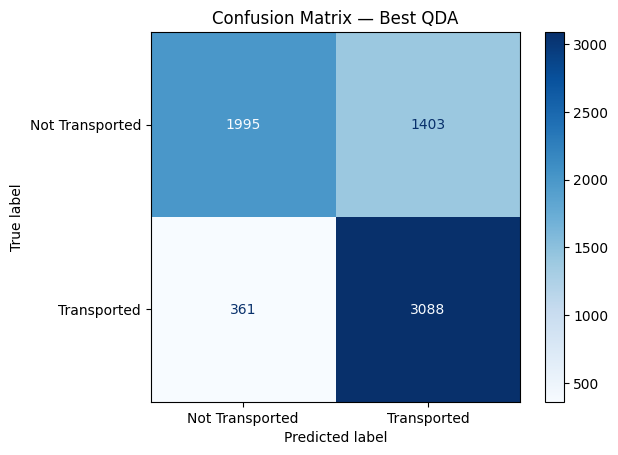

In [13]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    x_train,
    y_train,
    display_labels=["Not Transported", "Transported"],
    cmap="Blues"
)

plt.title("Confusion Matrix — Best QDA")
plt.grid(False)
plt.show()